# (SUPERSEDED) Coffee Lake statistical notebook

Verbatim from `pc1_instructiontype_expanded_statistical.ipynb`, kept only for provenance of
the CSVs that shipped in the Coffee Lake folder.

> **Not part of the replication path.** It reads the **Coffee Lake** sensor/RAPL data but
> loads the **Arrow Lake** `runinfo.pkl`, so its per-workload windows do not match the data
> being cut (issue K7). `rq1_E1_coffeelake.ipynb` is the correct Coffee Lake RQ1 path.


### Parse the Teensy stream


In [1]:
#this method is updated since Oct 21. A better implementation would be to skip the header, then use vectorized operation in numpy.
#binparserGraph
#binparserTemp
#temporary binary parser before we can get xml analysis working # NOT TEMPORARY ANYMORE...

import os
import struct
import pandas as pd
import numpy as np

def parse_payload(payload: bytes):
    # payload = 4B header + 8B timestamp + 70B data (14×5B entries)
    timestamp = struct.unpack('<Q', payload[4:12])[0]
    entries = payload[12:]
    data_dict = {}
    for i in range(0, len(entries), 5):
        char_id = chr(entries[i])
        value = struct.unpack('<f', entries[i+1:i+5])[0]
        data_dict[char_id] = value
    return timestamp, data_dict

def parse_binary_folder(folder_path: str):
    # 4-byte discard field, then 8-byte timestamp, then 16 × (1-byte id + 4-byte float)
    record_dtype = np.dtype([
        ('_discard', '4u1'),                 # 4 bytes
        ('timestamp', '<u8'),                # 8 bytes (uint64)
        ('pairs', [('id', 'u1'), ('data', '<f4')], (16,))  # 16 × (1+4)
    ])
    record_size = record_dtype.itemsize  # should be 92 bytes

    files = sorted(
        [f for f in os.listdir(folder_path) if f.startswith('data') and f.endswith('.bin')],
        key=lambda x: int(x[4:-4])
    )

    timestamps_all = []
    id_arrays = {i: [] for i in range(16)}  # accumulate data columns by slot
    id_chars = None                         # to hold column names (char IDs)

    for filename in files:
        path = os.path.join(folder_path, filename)

        with open(path, 'rb') as f:
            data_bytes = f.read()  # read entire file (no header)
            n_records = len(data_bytes) // record_size
            if n_records == 0:
                continue

            # vectorized read
            arr = np.frombuffer(data_bytes, dtype=record_dtype, count=n_records)

            timestamps = arr['timestamp']
            ids = arr['pairs']['id']       # shape (n_records, 16)
            vals = arr['pairs']['data']    # shape (n_records, 16)

            timestamps_all.append(timestamps)

            # verify consistent IDs per column
            first_ids = ids[0, :]
            if not np.all(ids == first_ids):
                mismatched = np.nonzero(~np.all(ids == first_ids, axis=1))[0][:5]
                print(f"\n[DEBUG] ID mismatch in file {filename}: showing first {len(mismatched)} bad rows")
                print("Expected IDs (bytes):", " ".join(f"{b:02X}" for b in first_ids))
                for idx in mismatched:
                    raw_hex = " ".join(f"{b:02X}" for b in ids[idx])
                    print(f"  Row {idx:>6}: {raw_hex}")
                raise ValueError(f"File {filename} has mixed IDs per column!")

            # store char representations once (from first file)
            if id_chars is None:
                id_chars = [chr(x) for x in first_ids]

            # accumulate per-ID arrays
            for i, id_val in enumerate(first_ids):
                id_arrays[i].append(vals[:, i])

    if not timestamps_all:
        raise ValueError("No valid records found in folder!")

    # concatenate across files
    timestamps_all = np.concatenate(timestamps_all)
    data_cols = {}
    for i, chunks in id_arrays.items():
        if len(chunks) == 0:
            continue
        colname = id_chars[i] if id_chars is not None else f"id_{i}"
        data_cols[colname] = np.concatenate(chunks)

    # Build DataFrame
    df = pd.DataFrame(data_cols)
    df.insert(0, "timestamp", timestamps_all.astype(np.uint64))

    return df

def find_rollovers(df):
    if df['timestamp'].dtype != 'uint64':
        df['timestamp'] = df['timestamp'].astype('uint64')

    # Diff using int64 to preserve exact rollover detection
    diffs = df['timestamp'].astype('int64').diff()

    rollover_points = df.index[diffs < 0].tolist()

    for idx in rollover_points:
        t_before = df.loc[idx - 1, 'timestamp']
        t_after = df.loc[idx, 'timestamp']
        print(f"Timestamp rollover at index {idx}: {t_before} → {t_after}")

    return rollover_points

# Example usage:
df = parse_binary_folder('../../data/E1-coffeelake-instructions/teensy')
print(df.head(150))

print (df.iloc[12:75].head(10))

rollover = find_rollovers(df)
print(rollover)

print(df.shape)

corrected_df = df # this is just bandaid for things that still expect "corrected df"

          timestamp         A         B         C         D         H  \
0    17374778951835  1.143878  0.057194  0.903664  0.228776  0.022878   
1    17374779549002  1.315460  0.057194  1.052368  0.228776  0.000000   
2    17374780146419  0.995174  0.057194  0.800715  0.228776  0.022878   
3    17374780743710  1.121001  0.057194  0.857909  0.228776  0.000000   
4    17374781340877  1.029491  0.057194  0.857909  0.228776  0.022878   
..              ...       ...       ...       ...       ...       ...   
145  17374865552059  1.029491  0.057194  0.846470  0.228776  0.022878   
146  17374866149600  1.086684  0.057194  0.903664  0.228776  0.022878   
147  17374866747184  1.201072  0.057194  1.143878  0.228776  0.000000   
148  17374867344559  1.212511  0.057194  0.972297  0.228776  0.022878   
149  17374867941767  1.143878  0.057194  0.972297  0.228776  0.022878   

            I         J         K         Y         Z         O         P  \
0    2.699553  0.022878  0.125827  3.753040  4

### Parse RAPL


In [2]:
#use this to read rapl if it's PKG, DRAM and PSYS
SAMP_PATH = "../../data/E1-coffeelake-instructions/rapl"

import os
import glob
import numpy as np
import pandas as pd
import struct

import os
import glob
import numpy as np
import pandas as pd

def read_rapl_binaries(SAMP_PATH):
    """
    Reads all binary files written by flush_to_file() in C:
        fwrite(ts_buf, sizeof(int64_t), BUF_SIZE, f);
        fwrite(e_buf, sizeof(float),   BUF_SIZE, f);

    Each file contains two contiguous arrays:
        - timestamps (int64 nanoseconds)
        - energy samples (float32 joules)
    Returns a pandas DataFrame with columns ['timestamp_ns', 'energy'].
    """

    # Match pattern like rapl_YYYYMMDD_HHMMSS_###.bin
    files = sorted(glob.glob(os.path.join(SAMP_PATH, "rapl_????????_??????_???.bin")))
    if not files:
        raise FileNotFoundError(f"No RAPL binary files found in {SAMP_PATH}")

    dfs = []
    for fname in files:
        with open(fname, "rb") as f:
            raw = f.read()

        # Each file contains BUF_SIZE timestamps (8 bytes each) + BUF_SIZE floats (4 bytes each) *3
        # So total length must be divisible by 20
        if len(raw) % 20 != 0:
            raise ValueError(f"File {fname} length {len(raw)} not multiple of 20 bytes")

        # Determine number of samples
        total_bytes = len(raw)
        n_samples = total_bytes // 20

        # Split manually
        ts_bytes = raw[:n_samples * 8]
        pkg_bytes = raw[n_samples * 8 : n_samples * 12]
        dram_bytes  =  raw[n_samples * 12 : n_samples * 16 ]
        psys_bytes  = raw[n_samples * 16:]

        timestamps = np.frombuffer(ts_bytes, dtype="<u8")  # little-endian int64
        energy_pkg     = np.frombuffer(pkg_bytes,  dtype="<f4")  # little-endian float32
        energy_dram     = np.frombuffer(dram_bytes,  dtype="<f4")  # little-endian float32
        energy_psys     = np.frombuffer(psys_bytes,  dtype="<f4")  # little-endian float32


        if len(timestamps) != len(energy_pkg):
            raise ValueError(f"Timestamp and energy count mismatch in {fname}")

        df = pd.DataFrame({
            "timestamp": timestamps,
            "energy_pkg" : energy_pkg,
            "energy_dram" : energy_dram,
            "energy_psys" : energy_psys,
        })
        df["energy"] = df["energy_pkg"]
        dfs.append(df)

    # Combine all
    df_all = pd.concat(dfs, ignore_index=True)
    return df_all

df_rapl = read_rapl_binaries(SAMP_PATH)
print(df_rapl.head(10))
print(df_rapl.shape)

        timestamp  energy_pkg  energy_dram  energy_psys    energy
0  17352798316990    0.008789     0.002563          0.0  0.008789
1  17352799303162    0.010559     0.003052          0.0  0.010559
2  17352800251703    0.007507     0.001709          0.0  0.007507
3  17352801291663    0.008301     0.002075          0.0  0.008301
4  17352802276547    0.008545     0.001953          0.0  0.008545
5  17352803292965    0.006409     0.001282          0.0  0.006409
6  17352804299661    0.005554     0.001404          0.0  0.005554
7  17352805268420    0.010620     0.003235          0.0  0.010620
8  17352806310943    0.008789     0.002319          0.0  0.008789
9  17352807284294    0.007263     0.002136          0.0  0.007263
(180000, 5)


### Clean RAPL


Index(['timestamp', 'energy_pkg', 'energy_dram', 'energy_psys', 'energy'], dtype='object')
0.032433912
0.14483643
outliers:
Empty DataFrame
Columns: [timestamp, energy_pkg, energy_dram, energy_psys, energy]
Index: []
pruned 0 outliers
0.032433912
(180000, 5)
17532794004373
17352798316990
17442795548746.117
outliers:
Empty DataFrame
Columns: [timestamp, energy_pkg, energy_dram, energy_psys, energy]
Index: []
pruned 0 outliers
17442795548746.117
(180000, 5)
Found these rows duplicated observations.
             timestamp  energy_pkg  energy_dram  energy_psys    energy
6881    17359679263255    0.003784     0.000977          0.0  0.003784
16881   17359679263255    0.003784     0.000977          0.0  0.003784
6882    17359680225270    0.004578     0.000977          0.0  0.004578
16882   17359680225270    0.004578     0.000000          0.0  0.004578
18881   17371679024279    0.003601     0.000854          0.0  0.003601
28881   17371679024279    0.003601     0.000854          0.0  0.003601
1

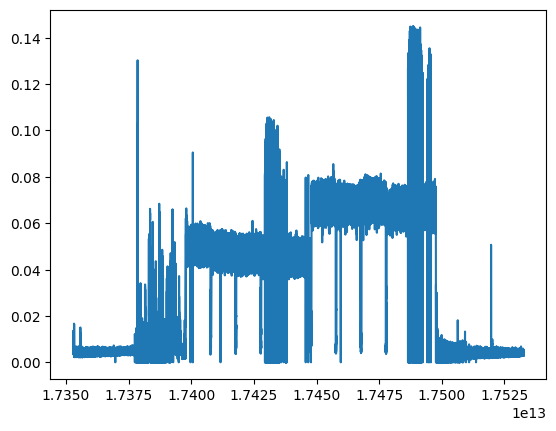

In [3]:
# data cleaning steps for RAPL
# prune outliers that look like 262143.968750, cause is unclear.
print(df_rapl.columns)
print(df_rapl["energy_pkg"].mean())
print(df_rapl["energy_pkg"].max())

df_outliers = df_rapl[df_rapl["energy_pkg"] > 200000]
print("outliers:")
print(df_outliers)

df_temp2 = df_rapl[df_rapl["energy_pkg"] < 200000]
print(f"pruned {len(df_rapl) - len(df_temp2)} outliers")
print(df_temp2["energy_pkg"].mean())
print(df_temp2.shape)

df_rapl=df_temp2

print(df_rapl["timestamp"].max())
print(df_rapl["timestamp"].min())
print(df_rapl["timestamp"].mean())

df_outliers = df_rapl[df_rapl["timestamp"] == 0]
print("outliers:")
print(df_outliers)

df_temp3 = df_rapl[df_rapl["timestamp"] != 0]
print(f"pruned {len(df_rapl) - len(df_temp3)} outliers")
print(df_temp3["timestamp"].mean())
print(df_temp3.shape)
df_rapl = df_temp3


duplicated_rows_df = df_rapl[df_rapl.duplicated(subset = ["timestamp"], keep = False)]
duplicated_rows_df = duplicated_rows_df.sort_values(by="timestamp")
print("Found these rows duplicated observations.")
print(duplicated_rows_df)
df_temp4 = df_rapl.drop_duplicates(subset=["timestamp"], keep= 'first')
print(f"dropping {len(df_rapl) - len(df_temp4)} duplicated rows")
df_rapl = df_temp4

import matplotlib.pyplot as plt
plt.plot(df_rapl["timestamp"].values,df_rapl["energy_pkg"].values)
plt.show()

### Derive power


In [4]:
def compute_power_from_energy(df: pd.DataFrame,
                              time_col: str = "timestamp",
                              energy_col: str = "energy") -> pd.DataFrame:
    """
    Compute instantaneous power (Watts) from cumulative energy (Joules)
    using timestamp differences in nanoseconds.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing 'timestamp' (ns) and 'energy' (Joule).
    time_col : str, default 'timestamp'
        Column name for timestamp (in nanoseconds).
    energy_col : str, default 'energy'
        Column name for cumulative energy (in Joules).

    Returns
    -------
    pd.DataFrame
        Copy of df with a new 'power' column (float32, in Watts).
    """
    result = df.copy()

    # Compute differences
    dE = result[energy_col]        # ΔEnergy (J)
    dT_ns = result[time_col].diff()        # ΔTime (ns)
    
    # Avoid divide-by-zero or negative intervals
    dT_ns = dT_ns.replace(0, np.nan)

    # Convert ns → seconds and compute power (Watts = J / s)
    result["power"] = (dE / (dT_ns * 1e-9)).astype("float32")

    return result

df_rapl_watt = compute_power_from_energy(df_rapl).dropna()
df_rapl_watt["dram_rapl"] = compute_power_from_energy(df_rapl, energy_col="energy_dram").dropna()["power"]
print(df_rapl_watt.shape)
print(df_rapl_watt.head(5))

(179989, 7)
        timestamp  energy_pkg  energy_dram  energy_psys    energy      power  \
1  17352799303162    0.010559     0.003052          0.0  0.010559  10.707140   
2  17352800251703    0.007507     0.001709          0.0  0.007507   7.914602   
3  17352801291663    0.008301     0.002075          0.0  0.008301   7.981827   
4  17352802276547    0.008545     0.001953          0.0  0.008545   8.676069   
5  17352803292965    0.006409     0.001282          0.0  0.006409   6.305173   

   dram_rapl  
1   3.094549  
2   1.801698  
3   1.995457  
4   1.983102  
5   1.261035  


### Clock offset


In [9]:
print(df_rapl_watt.head(5))
df_rapl_watt["timestamp"] = df_rapl_watt["timestamp"] - 8642644546100
print(df.head(5))

        timestamp  energy_pkg  energy_dram  energy_psys    energy      power  \
1  11817131676212    0.000000          0.0          0.0  0.000000   0.000000   
2  11817132610181    0.029358          0.0          0.0  0.029358  31.433495   
3  11817133744396    0.024231          0.0          0.0  0.024231  21.363636   
4  11817134633226    0.022339          0.0          0.0  0.022339  25.132891   
5  11817135717780    0.000000          0.0          0.0  0.000000   0.000000   

   dram_rapl  
1        0.0  
2        0.0  
3        0.0  
4        0.0  
5        0.0  
        timestamp         A         B         C         D         H         I  \
0  11847837392042  2.024665  0.411796  2.196247  0.446113  2.756747  1.086684   
1  11847837908042  2.058981  0.434674  2.230563  0.446113  2.676676  1.086684   
2  11847838424042  2.058981  0.411796  2.207685  0.446113  2.733870  1.063807   
3  11847838941042  2.001787  0.411796  2.196247  0.434674  2.699553  1.063807   
4  11847839457042  2.024

### Bracket-merge


In [52]:
import pandas as pd
import numpy as np

def merge_by_bracketing_average(df1, df2, time_col="timestamp", t=500_000, suffix="_2"):
    """
    Bracket-merge df1 with df2 using integer timestamp arithmetic only.
    """

    # Sort
    df1 = df1.sort_values(time_col).reset_index(drop=True)
    df2 = df2.sort_values(time_col).reset_index(drop=True)

    t1 = df1[time_col].to_numpy(np.int64)
    t2 = df2[time_col].to_numpy(np.int64)

    # Get nearest right index in df2
    idx_right = np.searchsorted(t2, t1, side="left")
    idx_left = idx_right - 1

    # Clip to valid range inside df2
    idx_left = np.clip(idx_left, 0, len(t2) - 1)
    idx_right = np.clip(idx_right, 0, len(t2) - 1)

    # Gather timestamps
    t_left  = t2[idx_left]
    t_right = t2[idx_right]

    # Integer differences
    diff_left  = np.abs(t1 - t_left)
    diff_right = np.abs(t1 - t_right)

    # Require that left < t1 < right AND both within tolerance
    valid = (
        (diff_left <= t) &
        (diff_right <= t) &
        (t_left <= t1) &
        (t_right >= t1) &
        (idx_left != idx_right)
    )

    if not valid.any():
        return df1.iloc[0:0]   # empty

    # Filter indices
    df1_valid = df1[valid].reset_index(drop=True)
    left_idx  = idx_left[valid]
    right_idx = idx_right[valid]

    left_df2  = df2.iloc[left_idx].reset_index(drop=True)
    right_df2 = df2.iloc[right_idx].reset_index(drop=True)

    # Integer midpoint timestamp
    # (safe: stays int64)
    merged_time = (left_df2[time_col].to_numpy(np.int64)
                   + right_df2[time_col].to_numpy(np.int64)) // 2

    # Average only numeric columns, integer arithmetic
    df2_avg = left_df2.copy()
    numeric_cols = df2_avg.select_dtypes(include=[np.number]).columns

    for c in numeric_cols:
        df2_avg[c] = (left_df2[c].to_numpy(np.int64)
                      + right_df2[c].to_numpy(np.int64)) // 2

    # Write midpoint timestamp to separate column
    df2_avg[time_col + suffix] = merged_time

    # Merge side-by-side
    merged = pd.concat(
        [df1_valid.reset_index(drop=True),
         df2_avg.add_suffix(suffix)],
        axis=1
    )

    # Integer difference
    merged["timestamp_diff"] = (
        merged[time_col + suffix] - merged[time_col]
    ).astype(np.int64)

    return merged

df_rapl_watt["timestamp_1"] = df_rapl_watt["timestamp"]
corrected_df["timestamp_2"] = corrected_df["timestamp"]

print(df_rapl_watt.shape)
rapl_teensy_merged = merge_by_bracketing_average(df1=df_rapl_watt, df2=corrected_df, time_col="timestamp", t=500000, suffix="_2")
print(rapl_teensy_merged.shape)

(499987, 8)
(438241, 28)


### Subsystem totals


In [53]:
rapl_teensy_merged["cpu_total"] = (rapl_teensy_merged["Y_2"] + rapl_teensy_merged["Z_2"] +rapl_teensy_merged["U_2"]+rapl_teensy_merged["V_2"] )
rapl_teensy_merged["abs_total"] = (rapl_teensy_merged["A_2"]+rapl_teensy_merged["B_2"]+rapl_teensy_merged["C_2"]+rapl_teensy_merged["D_2"]+rapl_teensy_merged["H_2"]+rapl_teensy_merged["I_2"]+rapl_teensy_merged["J_2"]+rapl_teensy_merged["K_2"]+rapl_teensy_merged["Y_2"]+rapl_teensy_merged["Z_2"]+rapl_teensy_merged["O_2"]+rapl_teensy_merged["P_2"]+rapl_teensy_merged["Q_2"]+rapl_teensy_merged["R_2"]+rapl_teensy_merged["U_2"]+rapl_teensy_merged["V_2"])
rapl_teensy_merged["timestamp_s"] = rapl_teensy_merged["timestamp"] / 1000_000_000
rapl_teensy_merged.head(3)


,timestamp,energy_pkg,energy_dram,energy_psys,energy,power,dram_rapl,timestamp_1,timestamp_2,A_2,...,Q_2,R_2,U_2,V_2,timestamp_s_2,timestamp_2_2,timestamp_diff,cpu_total,abs_total,timestamp_s
0,11847837526156,0.023621,0.0,0.0,0.023621,23.593214,0.0,11847837526156,11847837650042,2,...,1,1,3,5,11847,11847837650042,123886,14,26,11847.837526
1,11847838524102,0.021423,0.0,0.0,0.021423,21.467434,0.0,11847838524102,11847838682542,2,...,1,1,3,5,11847,11847838682542,158440,14,26,11847.838524
2,11847839525895,0.000000,0.0,0.0,0.000000,0.000000,0.0,11847839525895,11847839715042,2,...,1,1,3,5,11847,11847839715042,189147,14,26,11847.839526


## Wilcoxon signed-rank on power


In [19]:
# performs Wilcoxon SIGN-RANK test for each workload type, comparing spontaneous measurement (Power) between RAPL and Measured value
# "Power" for RAPL is computed previously as a function of Reported (Energy delta since last update) / duration of update  

import scipy.stats

def run_tests (snippet, xname= "cpu_total", yname="power"):

    prescriptive = {}
    x = snippet[xname] # measurement
    y = snippet[yname] # rapl
    

    result = scipy.stats.wilcoxon(x, y, zero_method='wilcox', correction=False, alternative='two-sided', method='auto', axis=0, nan_policy='propagate', keepdims=False)
    print(result)
    prescriptive["W twotail"] = result.statistic
    prescriptive["p twotail"] = result.pvalue # have to report this becaue no theory supporting onesided test.

    result = scipy.stats.wilcoxon(x, y, zero_method='wilcox', correction=False, alternative='less', method='auto', axis=0, nan_policy='propagate', keepdims=False)
    print(result)

    # prescriptive["W less"] = result.statistic
    # prescriptive["p less"] = result.pvalue

    result = scipy.stats.wilcoxon(x, y, zero_method='wilcox', correction=False, alternative='greater', method='auto', axis=0, nan_policy='propagate', keepdims=False)
    print(result)
    # prescriptive["W"] = result.statistic
    # prescriptive["p value"] = result.pvalue



    print("onesided Wilcoxon result: p value < threshold (ie, 0.05) means x is <alternative> than y")

    # Effect size (Rank biserial correlation)
    def calculate_directional_r(group1, group2):
        res = scipy.stats.mannwhitneyu(group1, group2, alternative='two-sided') #workaround because wilcoxon rank sum in scipy returns test statistic of X or Y depends on which one is smaller. which means we dont know the direction.
        U1 = res.statistic
        n1, n2 = len(group1), len(group2)
        
        # Calculate Rank-Biserial Correlation
        # This formula ensures: 
        # Positive r = Group 1 is greater
        # Negative r = Group 2 is greater
        r = (2 * U1 / (n1 * n2)) - 1
        
        return r, res.pvalue

    # Example
    effectsize, p = calculate_directional_r(x, y)

    print(f"effectsize {effectsize}")
    print("rB: 0: negligible effect, 0.1: small effect, 0.3: medium effect, 0.5: large effect")
    prescriptive["rank biserial effectsize"] = effectsize

    print(f"x median {x.median()}")
    print(f"y median {y.median()}")

    # mean error
    me = (x - y).mean()
    print(me)
    prescriptive["me"] = me
    # mean absolute error
    mae = (x - y).abs().mean()
    print(mae)
    prescriptive["mae"] = mae

    prescriptive["xname"] = xname
    prescriptive["yname"] = yname 
    return prescriptive

with open('../../data/E2-arrowlake-instructions/runinfo.pkl', "rb") as file: 
    workloads = pickle.load(file)
#print(workloads)

samples = []
for workload in workloads: 
    start_ns = workload["start_ns"]
    end_ns = workload["end_ns"]
    workload_name = workload["name"]
    samples.append(rapl_teensy_merged[(rapl_teensy_merged["timestamp"] > start_ns) & (rapl_teensy_merged["timestamp"] < end_ns)])

samples_by_workload = {}
for i, workload in enumerate(workloads):
    if workload["name"] in samples_by_workload.keys():
        df1 = samples_by_workload[workload["name"]]
        df2 = samples[i]
        samples_by_workload[workload["name"]] = pd.concat([df1, df2], axis =0)
    else: 
        samples_by_workload[workload["name"]] = samples[i]
    # print(workload["name"])
    # print(samples_by_workload[workload["name"]].shape)

# no normalization for wilcoxon.    
# for i, workload in enumerate(workloads):
#     df1 = samples_by_workload[workload["name"]]
#     df1["diff"] = df1["power"] - df1["cpu_total"]
#     df1["diff_normalized"] = df1["diff"] / df1["cpu_total"] #use sensor measurement as base for normalization
 
# for i, sample in enumerate(list(samples_by_workload.values())):
#     print(type(sample))
#     # plt.scatter(sample.index, sample["area_a"], s=5, color='tab:orange', alpha=0.6, label="power (W)")
#     # plt.scatter(sample.index, sample["area_b"], s=5, color='tab:blue', alpha=0.6, label="CPU Total (W)")
#     # plt.scatter(sample.index, sample["diff"], s=5, color='tab:green', alpha=0.6, label="diff")
#     plt.scatter(sample.index, sample["diff_normalized"], s=5, color='tab:red', alpha=0.6, label="diff normals")
#     plt.show()

results = []
for i, sample in enumerate(samples_by_workload.values()):
    result = run_tests(sample)
    result["workload name"] = list(samples_by_workload.keys())[i].split(':')[1]
    results.append(result)
df_descriptive = pd.DataFrame(results)
df_descriptive['significance'] = np.where(df_descriptive['p twotail'] < 0.001, "p < 0.001", "ns")
#effect size interprept.
conditions = [
    df_descriptive["rank biserial effectsize"].abs() >= 0.5,
    df_descriptive["rank biserial effectsize"].abs() >= 0.3,
    df_descriptive["rank biserial effectsize"].abs() >= 0.1
]
#Labels
choices = ["Large", "Medium", "Small"]
df_descriptive['effectsize word'] = np.select(conditions, choices, default="Negligible")
# directionality 
conditions = [
    df_descriptive["rank biserial effectsize"] > 0, 
    df_descriptive["rank biserial effectsize"] == 0,
    df_descriptive["rank biserial effectsize"] < 0
]
choices = ["X is greater", "Equal", "X is smaller"]
df_descriptive['direction'] = np.select(conditions, choices, default="NA")
df_descriptive.to_csv("power_descriptive_statistics_wilcoxon_rank_biserial.csv", index=False)
# snippets = []
# results = []
# for i in range (0, len(segments) - 1): 
#     snippets.append(rapl_teensy_merged[(rapl_teensy_merged["timestamp"] >= segments[i]) & (rapl_teensy_merged["timestamp"] <= segments[i + 1])])
#     print(f"workload # {i}")
#     result = run_tests(snippets[i])
#     results.append(result)

# df_descriptive = pd.DataFrame(results)
# df_descriptive.to_csv("descriptive_statistics_wilcoxon.csv", index=False)


target_cols = ["p value"]

print(df_descriptive.dtypes)
df_descriptive_latexfriendly = df_descriptive.apply(lambda col: 
    col.map(lambda x: "p < 0.001" if (isinstance(x, (int, float)) and x < 0.001) else x) 
    if col.name in target_cols else col
)
df_descriptive_latexfriendly = df_descriptive_latexfriendly.applymap(lambda x: f"${x :.3f}$" if isinstance(x, (int, float)) else x) #g for significant

latex_code = df_descriptive_latexfriendly.to_latex(
    column_format='@{}lrr@{}', 
    escape=False,
    index=False  # Set to False if you don't want the index
)
print(latex_code)

print("if you notice the effectsize is negative and the ME and MAE isnt, this is because scipy.stats.wilcoxon pick whichever statistic is smaller to report. I dont control it.")


NameError: name 'rapl_teensy_merged' is not defined

## Outer-join + clip to workload span


[{'name': 'w1:fp64:idle', 'start_wall': '2026-05-05 19:04:12', 'start_ns': 11854073309704, 'end_wall': '2026-05-05 19:04:22', 'end_ns': 11864079625096, 'duration': 10.00626910199935, 'command': './code/combine_instruction --cores 20 --workload1 fp64 --workload2 idle --duration 10'}, {'name': 'w1:fp64:idle', 'start_wall': '2026-05-05 19:04:22', 'start_ns': 11864079794688, 'end_wall': '2026-05-05 19:04:32', 'end_ns': 11874085526834, 'duration': 10.005680668999048, 'command': './code/combine_instruction --cores 20 --workload1 fp64 --workload2 idle --duration 10'}, {'name': 'w1:int128:idle', 'start_wall': '2026-05-05 19:04:32', 'start_ns': 11874085727623, 'end_wall': '2026-05-05 19:04:42', 'end_ns': 11884091298049, 'duration': 10.005530438998903, 'command': './code/combine_instruction --cores 20 --workload1 int128 --workload2 idle --duration 10'}, {'name': 'w1:int32:idle', 'start_wall': '2026-05-05 19:04:42', 'start_ns': 11884091448086, 'end_wall': '2026-05-05 19:04:52', 'end_ns': 11894096

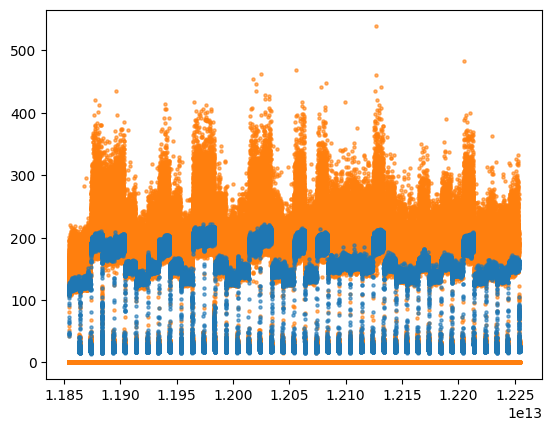

In [13]:
# this section intends to use a jumping window to split the observation into sections where we can observe if the sections are uniform.

# experiment info
with open('../../data/E2-arrowlake-instructions/runinfo.pkl', "rb") as file: 
    workloads = pickle.load(file)
print(workloads)

workload_start = workloads[0]["start_ns"]
workload_end = workloads[-1]["end_ns"]

print(f"experiment duration: {workload_start} to {workload_end}, lasted {(workload_end - workload_start)/1000_000_000} s")


df_teensy_original = corrected_df
df_teensy_original["cpu_total"] = df_teensy_original["Y"] + df_teensy_original["Z"] + df_teensy_original["U"] + df_teensy_original["V"]
df_rapl_original = df_rapl_watt
print(df_teensy_original.columns) 
print(df_teensy_original.shape)
print(df_rapl_original.columns) 
print(df_rapl_original.shape)

df_teensy_1 = df_teensy_original.set_index("timestamp")
df_rapl_1 = df_rapl_original.set_index("timestamp")
df_merged_outer = pd.merge(df_teensy_1, df_rapl_1, left_index=True, right_index=True, how='outer')
print(df_merged_outer.head())

df_merged_outer = df_merged_outer[(df_merged_outer.index >= workload_start) & (df_merged_outer.index <= workload_end)]

# 1. Create a mask and Group IDs
is_not_nan = df_merged_outer['power'].notna()
group_id = is_not_nan.cumsum()

# 2. Count how many NaNs are in each group
# We only group the rows where 'a' was actually NaN
nan_counts = df_merged_outer[df_merged_outer['power'].isna()].groupby(group_id).size()

# 3. Include the "Zeroes"
# Some non-NaN values might have 0 NaNs following them.
# We reindex to include every group ID from 1 to the total count of non-NaNs.
total_non_nans = is_not_nan.sum()
all_gaps = nan_counts.reindex(np.arange(1, total_non_nans + 1), fill_value=0)

# 4. Final Statistics
stats = {
    'mean': all_gaps.mean(),
    'median': all_gaps.median(),
    'max': all_gaps.max(),
    'min': all_gaps.min()
}

print(stats)
all_gaps = all_gaps.sort_values(ascending = False)
#print(all_gaps.head())
plt.scatter(df_merged_outer.index, df_merged_outer["power"], s=5, color='tab:orange', alpha=0.6, label="rapl")
plt.scatter(df_merged_outer.index, df_merged_outer["cpu_total"], s=5, color='tab:blue', alpha=0.6, label="measured")
plt.show()


## `integrate_dual_cadence`


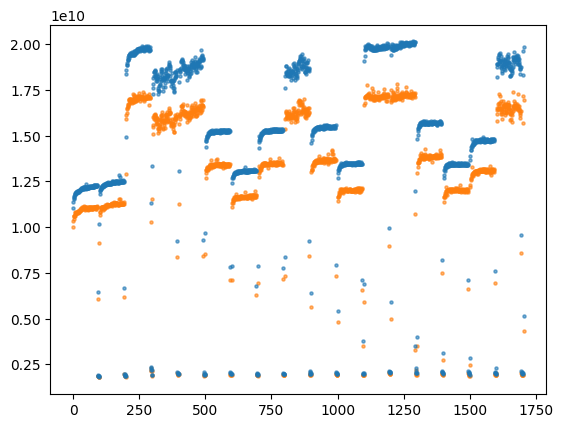

In [14]:
import pandas as pd
import numpy as np
from scipy.integrate import trapezoid

def integrate_dual_cadence(df, col1, col2, window = 10):
    # 1. Identify rows where 'a' is valid
    is_a_valid = df[col1].notna()
    
    # 2. Create Window IDs based on every 10 valid 'a' values
    # cumsum increments at every valid 'a', then // 10 groups them
    # We subtract 1 so the first group is 0
    a_group_id = (is_a_valid.cumsum() - 1) // window
    
    # 3. Handle Column B's range:
    # Column B needs to integrate everything from the first valid 'a' in the group
    # to just before the first 'a' of the NEXT group.
    # a_group_id naturally covers this range for every row.
    
    # 4. Define the integration logic
    def perform_integration(group):
        # -- Integration for A --
        # Filter only non-NaN a values
        a_data = group[col1].dropna()
        # Trapezoid needs at least 2 points to calculate area
        area_a = scipy.integrate.trapezoid(y=a_data.values, x=a_data.index, dx=1.0, axis=-1) if len(a_data) > 1 else 0
        
        # -- Integration for B --
        # Filter only non-NaN b values
        # This takes all rows in the 10-point 'a' window
        b_data = group[col2].dropna()
        area_b = scipy.integrate.trapezoid(y=b_data.values, x=b_data.index, dx=1.0, axis=-1) if len(b_data) > 1 else 0
        # print(a_data.index)
        # print(len(a_data.index))
        # print(b_data.index)
        # print(len(b_data.index))
        # print("break")

        return pd.Series({'area_a': area_a, 'area_b': area_b})

    # 5. Execute GroupBy
    # We only process groups where a_group_id >= 0 (ignores NaNs at the very start)
    results_df = df[a_group_id >= 0].groupby(a_group_id).apply(perform_integration)
    
    return results_df

# Example usage with dummy data
# df = pd.DataFrame({'a': [...], 'b': [...]})
integrated_results = integrate_dual_cadence(df_merged_outer.head(500000), "power", "cpu_total", window=100)

plt.scatter(integrated_results.index, integrated_results["area_a"], s=5, color='tab:orange', alpha=0.6, label="power (W)")
plt.scatter(integrated_results.index, integrated_results["area_b"], s=5, color='tab:blue', alpha=0.6, label="CPU Total (W)")
plt.show()

## Per-instruction-set energy samples


In [ ]:
#prepare KW test sample
with open('../../data/E2-arrowlake-instructions/runinfo.pkl', "rb") as file: 
    workloads = pickle.load(file)
#print(workloads)

samples_kw = []
for workload in workloads: 
    start_ns = workload["start_ns"]
    end_ns = workload["end_ns"]
    workload_name = workload["name"]
    samples_kw.append(df_merged_outer[(df_merged_outer.index > start_ns) & (df_merged_outer.index < end_ns)])

samples_integrals_kw = []
for sample in samples_kw: 
    samples_integrals_kw.append(integrate_dual_cadence(sample, "power", "cpu_total", window=100))

# for i, sample in enumerate(samples):
#     plt.scatter(samples_integrals[i].index, samples_integrals[i]["area_a"], s=5, color='tab:orange', alpha=0.6, label="power (W)")
#     plt.scatter(samples_integrals[i].index, samples_integrals[i]["area_b"], s=5, color='tab:blue', alpha=0.6, label="CPU Total (W)")
#     plt.show()

samples_by_workload_kw = {}
for i, workload in enumerate(workloads):
    if workload["name"] in samples_by_workload_kw.keys():
        df1 = samples_by_workload_kw[workload["name"]]
        df2 = samples_integrals_kw[i]
        samples_by_workload_kw[workload["name"]] = pd.concat([df1, df2], axis =0)
    else: 
        samples_by_workload_kw[workload["name"]] = samples_integrals_kw[i]
    # print(workload["name"])
    # print(samples_by_workload_kw[workload["name"]].shape)
    
for i, workload in enumerate(workloads):
    df1 = samples_by_workload_kw[workload["name"]]
    df1["diff"] = df1["area_a"] - df1["area_b"]
    df1["diff_normalized"] = df1["diff"] / df1["area_b"]

for i, sample in enumerate(list(samples_by_workload_kw.values())):
    print(type(sample))
    # plt.scatter(sample.index, sample["area_a"], s=5, color='tab:orange', alpha=0.6, label="power (W)")
    # plt.scatter(sample.index, sample["area_b"], s=5, color='tab:blue', alpha=0.6, label="CPU Total (W)")
    # plt.scatter(sample.index, sample["diff"], s=5, color='tab:green', alpha=0.6, label="diff")
    # plt.scatter(sample.index, sample["diff_normalized"], s=5, color='tab:red', alpha=0.6, label="diff normals")
    # plt.show()
    

    

#segments = [17398106102790, 17408115632950, 17418125344082, 17428134473623, 17438142474785, 17448150626666, 17458160825127, 17468168994269, 17478177946304,17488185946880, 17498193747238]

# plot_cpu_vs_energy(rapl_teensy_merged, sample_factor=100, time_col="timestamp", segments=segments)
# for i, workload in enumerate(workloads):
#     print(f"#{i}: {workload['name']}")



<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


## Kruskal-Wallis + Dunn


2159.4429458929717
0.0
group
0    3259.794554
8    2992.853960
5    2937.997525
7    2339.254950
6    2072.467822
9    2031.881188
4    1846.272277
2    1085.259901
3     985.524752
1     653.693069
Name: overall_rank, dtype: float64


C:\Users\andyh\AppData\Local\Temp\ipykernel_17776\2667136197.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_kruskal_display = pd.concat([df_kruskal_display, sample_df], axis =0)


         median      mean
group                    
0     -0.098518 -0.093876
1     -0.136081 -0.129365
2     -0.128384 -0.121201
3     -0.130546 -0.122778
4     -0.116096 -0.110334
5     -0.104131 -0.099563
6     -0.113958 -0.108161
7     -0.110922 -0.105856
8     -0.103486 -0.098602
9     -0.114499 -0.108194
Index([1, 3, 2, 4, 9, 6, 7, 5, 8, 0], dtype='int64', name='group')
       overall_rank    median      mean  orderPositiveCorrelation
group                                                            
0       3259.794554 -0.098518 -0.093876                         9
1        653.693069 -0.136081 -0.129365                         0
2       1085.259901 -0.128384 -0.121201                         2
3        985.524752 -0.130546 -0.122778                         1
4       1846.272277 -0.116096 -0.110334                         3
5       2937.997525 -0.104131 -0.099563                         7
6       2072.467822 -0.113958 -0.108161                         5
7       2339.254950 -0.1109

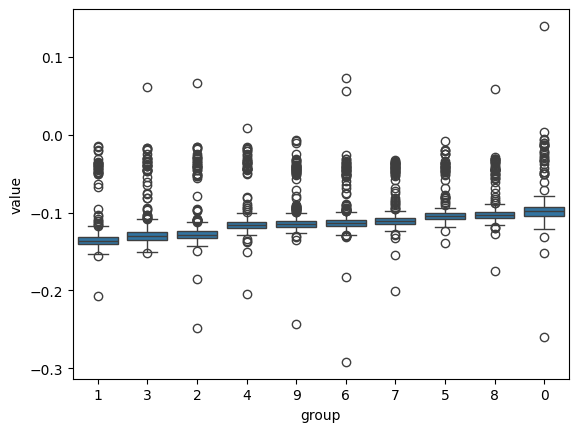

dict_keys(['w1:fp64:idle', 'w1:int128:idle', 'w1:int32:idle', 'w1:int64:idle', 'w1:AVX2:idle', 'w1:fp32:idle', 'w1:SSE2:idle', 'w1:SSE:idle', 'w1:MMX:idle', 'w1:AVX:idle'])
   group    workloadname
0      0    w1:fp64:idle
1      1  w1:int128:idle
2      2   w1:int32:idle
3      3   w1:int64:idle
4      4    w1:AVX2:idle
5      5    w1:fp32:idle
6      6    w1:SSE2:idle
7      7     w1:SSE:idle
8      8     w1:MMX:idle
9      9     w1:AVX:idle
   group  overall_rank    median      mean  orderPositiveCorrelation  \
0      0   3259.794554 -0.098518 -0.093876                         9   
1      1    653.693069 -0.136081 -0.129365                         0   
2      2   1085.259901 -0.128384 -0.121201                         2   
3      3    985.524752 -0.130546 -0.122778                         1   
4      4   1846.272277 -0.116096 -0.110334                         3   
5      5   2937.997525 -0.104131 -0.099563                         7   
6      6   2072.467822 -0.113958 -0.108161      

C:\Users\andyh\AppData\Local\Temp\ipykernel_17776\2667136197.py:89: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order_with_names)


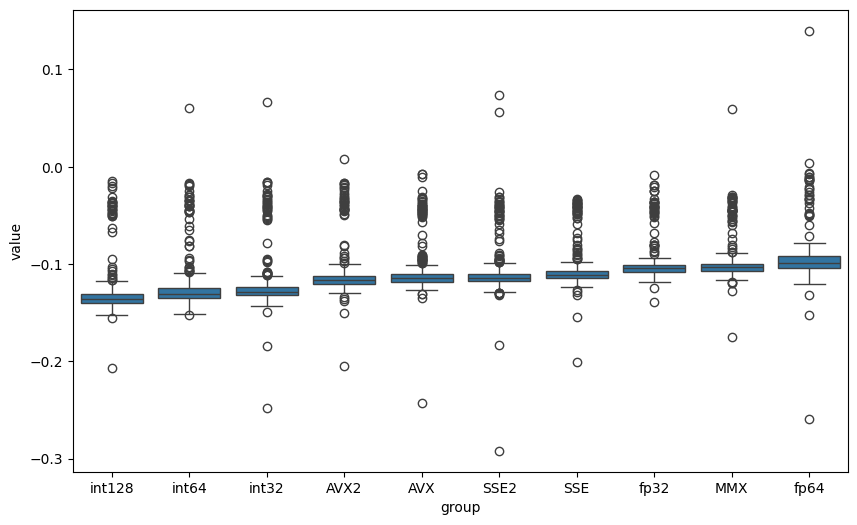

In [16]:
# perform kruskal wallis H test on normalized difference for data collected in each instruction set type workload.
# visualize using box plot 
# performs dunns test to determining if the differences are statistically significant 

writepath = "./"

from scipy.stats import kruskal

kruskal_sample = []
for sample in list(samples_by_workload_kw.values()):
    kruskal_sample.append(sample["diff_normalized"])

# Perform Kruskal-Wallis H-test
result = kruskal(*kruskal_sample)

print(result.statistic)
print(result.pvalue)

df_kruskal_display = pd.DataFrame(columns=["value", "group"])
for i, sample in enumerate(kruskal_sample):
    sample_df = pd.DataFrame()
    sample_df["value"] = sample
    sample_df["group"] = i
    df_kruskal_display = pd.concat([df_kruskal_display, sample_df], axis =0)

from scipy.stats import rankdata
df_kruskal_descriptive = pd.DataFrame()

# Combine your data into a DataFrame
# Assume 'value' is the score and 'group' is the category
df_kruskal_display['overall_rank'] = rankdata(df_kruskal_display['value'])

# Get the ranking of the groups
group_rankings = df_kruskal_display.groupby('group')['overall_rank'].mean().sort_values(ascending=False)
df_kruskal_descriptive = df_kruskal_display.groupby("group")["overall_rank"].mean()
print(group_rankings)

import seaborn as sns
import matplotlib.pyplot as plt

# Sort the groups by their median value to visualize the ranking
order = df_kruskal_display.groupby('group')['value'].median().sort_values().index
df_kruskal_median = pd.DataFrame()
df_kruskal_median["median"] = df_kruskal_display.groupby("group")["value"].median()
df_kruskal_median["mean"] = df_kruskal_display.groupby("group")["value"].mean()

df_kruskal_descriptive = pd.merge(df_kruskal_descriptive, df_kruskal_median, on="group")
print(df_kruskal_median)
#df_kruskal_order = df_kruskal_order.set_index("order")
print(order)
order_by_group = pd.Series(range(len(order)), index=order).sort_index()
df_kruskal_descriptive["orderPositiveCorrelation"] = order_by_group
print(df_kruskal_descriptive)

sns.boxplot(x='group', y='value', data=df_kruskal_display, order=order)
plt.show()
print(samples_by_workload_kw.keys())
df_workload_results = pd.DataFrame()
df_workload_results["workloadname"] = samples_by_workload_kw.keys()
df_workload_results = df_workload_results.reset_index(names="group")
print(df_workload_results)
df_kruskal_descriptive = pd.merge(df_kruskal_descriptive, df_workload_results, on="group")
print(df_kruskal_descriptive)
df_kruskal_descriptive['workloadname'] = df_kruskal_descriptive['workloadname'].apply(lambda x: x.split(':')[1])
print(df_kruskal_descriptive)
df_kruskal_descriptive.to_csv((writepath + "Energy_kruskal_results_descriptive_workloadranking.csv"), index = False)
workload_name_mapping = df_kruskal_descriptive.set_index('group')['workloadname'].to_dict()


import scikit_posthocs as sp

# Assuming 'data' is your list of 10 groups
# We pass the list directly to the dunn test function
print("columns")
print(df_kruskal_display.columns)
p_values = sp.posthoc_dunn(df_kruskal_display,val_col="value", group_col="group", p_adjust='bonferroni')
p_values = p_values.mask(p_values < 0.001, "p < 0.001")

p_values = p_values.rename(index=workload_name_mapping, columns=workload_name_mapping)
print(p_values)
p_values.to_csv((writepath + "Energy_dunn_posthoc_pairwise_workload_comparison.csv"))

# df_kruskal_display["workload name"] = df_kruskal_display["group"].map(workload_name_mapping)
# sns.boxplot(x='group', y='value', data=df_kruskal_display, order=order)
order_with_names = [workload_name_mapping.get(id) for id in order]
plt.figure(figsize=(10, 6))
ax = sns.boxplot(data=df_kruskal_display, x='group', y='value', order=order)
# override the tick labels 
ax.set_xticklabels(order_with_names)
plt.show()




## Wilcoxon signed-rank on energy


In [21]:
# perform pairwise comparison for Energy data between RAPL and Teensy, using Wilconxon ranksum test

with open('../../data/E2-arrowlake-instructions/runinfo.pkl', "rb") as file: 
    workloads = pickle.load(file)
#print(workloads)


# samples = []
# for workload in workloads: 
#     start_ns = workload["start_ns"]
#     end_ns = workload["end_ns"]
#     workload_name = workload["name"]
#     samples.append(rapl_teensy_merged[(rapl_teensy_merged["timestamp"] > start_ns) & (rapl_teensy_merged["timestamp"] < end_ns)])

# samples_by_workload = {}
# for i, workload in enumerate(workloads):
#     if workload["name"] in samples_by_workload.keys():
#         df1 = samples_by_workload[workload["name"]]
#         df2 = samples[i]
#         samples_by_workload[workload["name"]] = pd.concat([df1, df2], axis =0)
#     else: 
#         samples_by_workload[workload["name"]] = samples[i]
    # print(workload["name"])
    # print(samples_by_workload[workload["name"]].shape)

# no normalization for wilcoxon.    
# for i, workload in enumerate(workloads):
#     df1 = samples_by_workload[workload["name"]]
#     df1["diff"] = df1["power"] - df1["cpu_total"]
#     df1["diff_normalized"] = df1["diff"] / df1["cpu_total"] #use sensor measurement as base for normalization
 
# for i, sample in enumerate(list(samples_by_workload.values())):
#     print(type(sample))
#     # plt.scatter(sample.index, sample["area_a"], s=5, color='tab:orange', alpha=0.6, label="power (W)")
#     # plt.scatter(sample.index, sample["area_b"], s=5, color='tab:blue', alpha=0.6, label="CPU Total (W)")
#     # plt.scatter(sample.index, sample["diff"], s=5, color='tab:green', alpha=0.6, label="diff")
#     plt.scatter(sample.index, sample["diff_normalized"], s=5, color='tab:red', alpha=0.6, label="diff normals")
#     plt.show()

results = []
for i, sample in enumerate(samples_by_workload_kw.values()):
    result = run_tests(sample, xname="area_a", yname="area_b")
    result["workload name"] = list(samples_by_workload_kw.keys())[i].split(':')[1]
    results.append(result)
df_descriptive = pd.DataFrame(results)
df_descriptive['significance'] = np.where(df_descriptive['p twotail'] < 0.001, "p < 0.001", "ns")
#effect size interprept.
conditions = [
    df_descriptive["rank biserial effectsize"].abs() >= 0.5,
    df_descriptive["rank biserial effectsize"].abs() >= 0.3,
    df_descriptive["rank biserial effectsize"].abs() >= 0.1
]
#Labels
choices = ["Large", "Medium", "Small"]
df_descriptive['effectsize word'] = np.select(conditions, choices, default="Negligible")
# directionality 
conditions = [
    df_descriptive["rank biserial effectsize"] > 0, 
    df_descriptive["rank biserial effectsize"] == 0,
    df_descriptive["rank biserial effectsize"] < 0
]
choices = ["X is greater", "Equal", "X is smaller"]
df_descriptive['direction'] = np.select(conditions, choices, default="NA")
df_descriptive.to_csv("Energy_descriptive_statistics_wilcoxon_rank_biserial.csv", index=False)
# snippets = []
# results = []
# for i in range (0, len(segments) - 1): 
#     snippets.append(rapl_teensy_merged[(rapl_teensy_merged["timestamp"] >= segments[i]) & (rapl_teensy_merged["timestamp"] <= segments[i + 1])])
#     print(f"workload # {i}")
#     result = run_tests(snippets[i])
#     results.append(result)

# df_descriptive = pd.DataFrame(results)
# df_descriptive.to_csv("descriptive_statistics_wilcoxon.csv", index=False)


target_cols = ["p value"]


WilcoxonResult(statistic=np.float64(8.0), pvalue=np.float64(6.433342159469221e-68))
WilcoxonResult(statistic=np.float64(8.0), pvalue=np.float64(3.2166710797346107e-68))
WilcoxonResult(statistic=np.float64(8.0), pvalue=np.float64(1.0))
onesided Wilcoxon result: p value < threshold (ie, 0.05) means x is <alternative> than y
effectsize -0.6609646113126164
rB: 0: negligible effect, 0.1: small effect, 0.3: medium effect, 0.5: large effect
x median 11293617398.104969
y median 12480140754.2305
-1180371319.3606467
1180477111.686636
WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(6.061596090070382e-68))
WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(3.030798045035191e-68))
WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(1.0))
onesided Wilcoxon result: p value < threshold (ie, 0.05) means x is <alternative> than y
effectsize -0.8335457308107048
rB: 0: negligible effect, 0.1: small effect, 0.3: medium effect, 0.5: large effect
x median 17127100520.64849
y medi